# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [1]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [2]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 599


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [24]:
# Set the API base URL
api_key = "b91c8aaf78c0d69f67c7d7f10e2e68c3"
url = "http://api.openweathermap.org/data/2.5/weather?"

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i > 0):
        set_count += 1
        record_count = 1

    # Create endpoint URL with each city
    city_url = f"{url}q={city}&appid={api_key}&units=metric"

    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        city_weather = requests.get(city_url).json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather['coord']['lat']
        city_lng = city_weather['coord']['lon']
        city_max_temp = city_weather['main']['temp_max']
        city_humidity = city_weather['main']['humidity']
        city_clouds = city_weather['clouds']['all']
        city_wind = city_weather['wind']['speed']
        city_country = city_weather['sys']['country']
        city_date = city_weather['dt']

        # Append the City information into city_data list
        city_data.append({"City": city,
                          "Lat": city_lat,
                          "Lng": city_lng,
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval
-----------------------------
Processing Record 1 of Set 1 | ribeira grande
Processing Record 2 of Set 1 | port-aux-francais
Processing Record 3 of Set 1 | puerto ayora
Processing Record 4 of Set 1 | yellowknife
Processing Record 5 of Set 1 | tarawa
Processing Record 6 of Set 1 | waitangi
Processing Record 7 of Set 1 | hermanus
Processing Record 8 of Set 1 | edinburgh of the seven seas
Processing Record 9 of Set 1 | agnibilekrou
Processing Record 10 of Set 1 | arraial do cabo
Processing Record 11 of Set 1 | badger
Processing Record 12 of Set 1 | anadyr
Processing Record 13 of Set 1 | thompson
Processing Record 14 of Set 1 | mont-tremblant
Processing Record 15 of Set 1 | taiohae
City not found. Skipping...
Processing Record 16 of Set 1 | adamstown
Processing Record 17 of Set 1 | saint-philippe
Processing Record 18 of Set 1 | longyearbyen
Processing Record 19 of Set 1 | hammerfest
Processing Record 20 of Set 1 | touros
Processing Record 21 of Set 1 | linxia cheng

In [5]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          542
Lat           542
Lng           542
Max Temp      542
Humidity      542
Cloudiness    542
Wind Speed    542
Country       542
Date          542
dtype: int64

In [6]:
# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,ribeira grande,38.5167,-28.7000,17.22,77,20,4.63,PT,1739385466
1,port-aux-francais,-49.3500,70.2167,3.94,89,100,7.40,TF,1739385468
2,puerto ayora,-0.7393,-90.3518,27.53,88,81,1.79,EC,1739385469
3,yellowknife,62.4560,-114.3525,-30.71,76,75,2.06,CA,1739385301
4,tarawa,1.4190,172.9840,26.05,89,75,1.54,KI,1739385471


In [7]:
# Export the City_Data into a csv
import os
output_dir = "output_data"
os.makedirs(output_dir, exist_ok=True)
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [8]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,ribeira grande,38.5167,-28.7000,17.22,77,20,4.63,PT,1739385466
1,port-aux-francais,-49.3500,70.2167,3.94,89,100,7.40,TF,1739385468
2,puerto ayora,-0.7393,-90.3518,27.53,88,81,1.79,EC,1739385469
3,yellowknife,62.4560,-114.3525,-30.71,76,75,2.06,CA,1739385301
4,tarawa,1.4190,172.9840,26.05,89,75,1.54,KI,1739385471


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

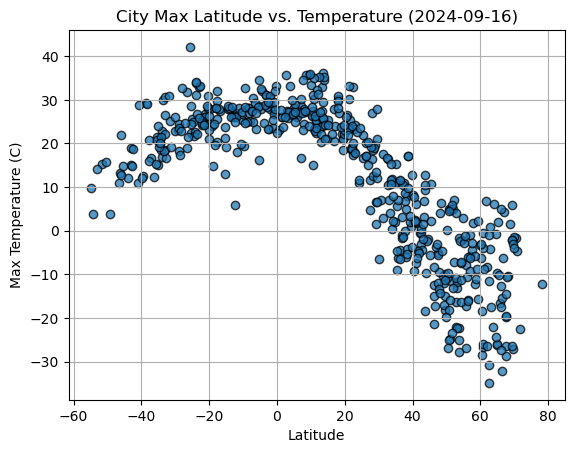

In [9]:
# Build scatter plot for latitude vs. temperature
plt.scatter(city_data_df["Lat"], city_data_df["Max Temp"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)

# Incorporate the other graph properties
plt.title("City Max Latitude vs. Temperature (2024-09-16)")
plt.xlabel("Latitude")
plt.ylabel("Max Temperature (C)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

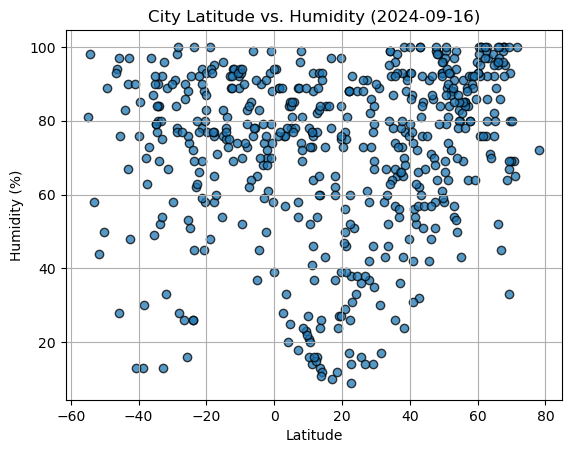

In [10]:
# Build the scatter plots for latitude vs. humidity
plt.scatter(city_data_df["Lat"], city_data_df["Humidity"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)

# Incorporate the other graph properties
plt.title("City Latitude vs. Humidity (2024-09-16)")
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

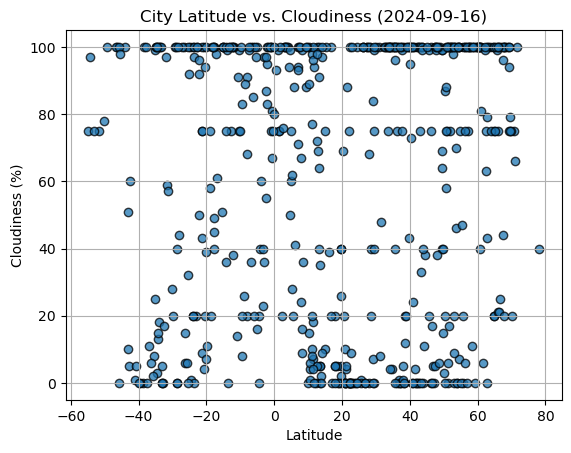

In [11]:
# Build the scatter plots for latitude vs. cloudiness
plt.scatter(city_data_df["Lat"], city_data_df["Cloudiness"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)

# Incorporate the other graph properties
plt.title("City Latitude vs. Cloudiness (2024-09-16)")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

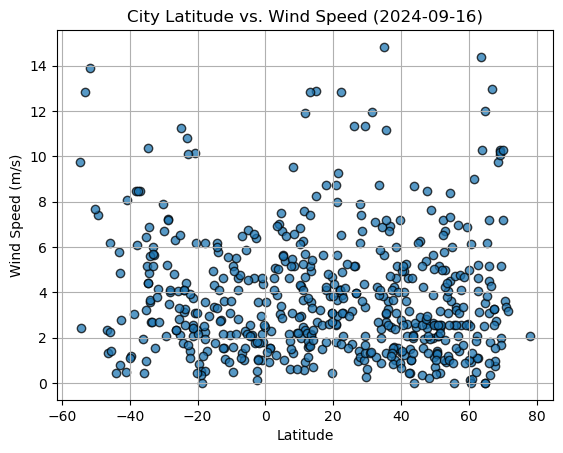

In [12]:
# Build the scatter plots for latitude vs. wind speed
plt.scatter(city_data_df["Lat"], city_data_df["Wind Speed"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)

# Incorporate the other graph properties
plt.title("City Latitude vs. Wind Speed (2024-09-16)")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [13]:
# Define a function to create Linear Regression plots
def plot_linear_regression(x_values, y_values, x_label, y_label, title, save_path):
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
    regress_values = x_values * slope + intercept
    line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
    plt.scatter(x_values, y_values, edgecolors="black", linewidths=1, marker="o", alpha=0.75)
    plt.plot(x_values, regress_values, "r-")
    plt.annotate(line_eq, (x_values.mean(), y_values.mean()), fontsize=15, color="red")
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    ply.show()

In [14]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df[city_data_df["Lat"] >= 0]

# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,ribeira grande,38.5167,-28.7000,17.22,77,20,4.63,PT,1739385466
3,yellowknife,62.4560,-114.3525,-30.71,76,75,2.06,CA,1739385301
4,tarawa,1.4190,172.9840,26.05,89,75,1.54,KI,1739385471
8,agnibilekrou,7.1344,-3.2047,28.51,58,94,1.84,CI,1739385475
10,badger,64.8000,-147.5333,-26.11,82,20,0.00,US,1739385478


In [15]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df[city_data_df["Lat"] <0]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
1,port-aux-francais,-49.3500,70.2167,3.94,89,100,7.40,TF,1739385468
2,puerto ayora,-0.7393,-90.3518,27.53,88,81,1.79,EC,1739385469
5,waitangi,-43.9535,-176.5597,12.12,83,100,0.45,NZ,1739385472
6,hermanus,-34.4187,19.2345,21.00,84,13,4.86,ZA,1739385473
7,edinburgh of the seven seas,-37.0676,-12.3116,16.69,73,11,8.49,SH,1739385474


###  Temperature vs. Latitude Linear Regression Plot

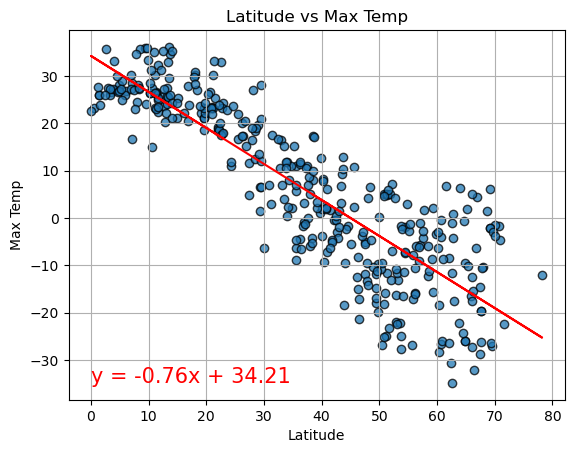

The R^2 value for Northern Hemisphere is: 0.7558354730078877


In [16]:
# Linear regression on Northern Hemisphere
slope, intercept, r_value, p_value, std_err = linregress(northern_hemi_df["Lat"], northern_hemi_df["Max Temp"])
lat = ["northern_hemi_df"]
regress_values = slope * northern_hemi_df["Lat"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
plt.scatter(northern_hemi_df["Lat"], northern_hemi_df["Max Temp"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)
plt.plot(northern_hemi_df["Lat"], regress_values, "r-", label="Regression Line")
plt.annotate(line_eq, (min(northern_hemi_df["Lat"]), min(northern_hemi_df["Max Temp"])), fontsize=15, color="red")
plt.title("Latitude vs Max Temp")
plt.xlabel("Latitude")
plt.ylabel("Max Temp")
plt.grid(True)
plt.show()
r_squared = r_value ** 2
print(f"The R^2 value for Northern Hemisphere is: {r_squared}")

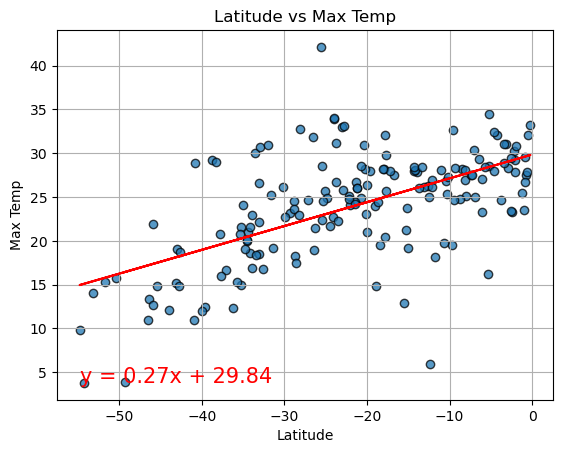

The R^2 value for Southern Hemisphere is: 0.3559741527297334


In [17]:
# Linear regression on Southern Hemisphere
slope, intercept, r_value, p_value, std_err = linregress(southern_hemi_df["Lat"], southern_hemi_df["Max Temp"])
lat = ["southern_hemi_df"]
regress_values = slope * southern_hemi_df["Lat"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
plt.scatter(southern_hemi_df["Lat"], southern_hemi_df["Max Temp"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)
plt.plot(southern_hemi_df["Lat"], regress_values, "r-", label="Regression Line")
plt.annotate(line_eq, (min(southern_hemi_df["Lat"]), min(southern_hemi_df["Max Temp"])), fontsize=15, color="red")
plt.title("Latitude vs Max Temp")
plt.xlabel("Latitude")
plt.ylabel("Max Temp")
plt.grid(True)
plt.show()
r_squared = r_value ** 2
print(f"The R^2 value for Southern Hemisphere is: {r_squared}")

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Humidity vs. Latitude Linear Regression Plot

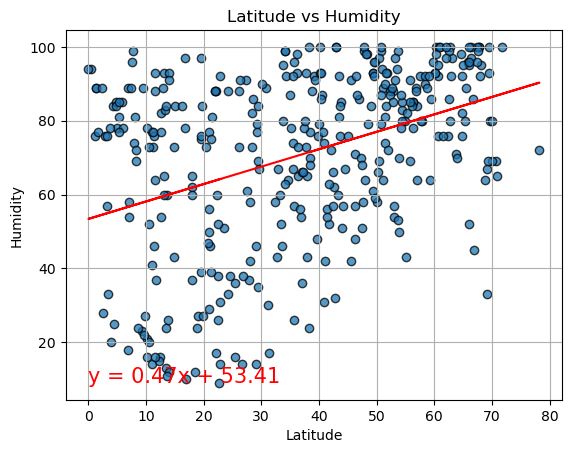

The R^2 value for Northern Hemisphere is: 0.1529897809951088


In [18]:
# Northern Hemisphere
slope, intercept, r_value, p_value, std_err = linregress(northern_hemi_df["Lat"], northern_hemi_df["Humidity"])
lat = ["northern_hemi_df"]
regress_values = slope * northern_hemi_df["Lat"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
plt.scatter(northern_hemi_df["Lat"], northern_hemi_df["Humidity"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)
plt.plot(northern_hemi_df["Lat"], regress_values, "r-", label="Regression Line")
plt.annotate(line_eq, (min(northern_hemi_df["Lat"]), min(northern_hemi_df["Humidity"])), fontsize=15, color="red")
plt.title("Latitude vs Humidity")
plt.xlabel("Latitude")
plt.ylabel("Humidity")
plt.grid(True)
plt.show()
r_squared = r_value ** 2
print(f"The R^2 value for Northern Hemisphere is: {r_squared}")

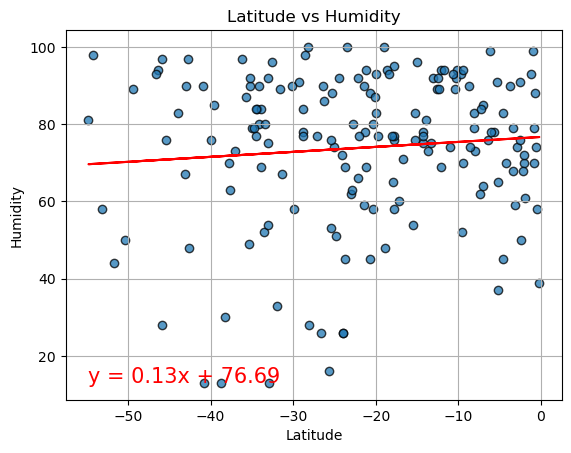

The R^2 value for Southern Hemisphere is: 0.008199606131298382


In [19]:
# Southern Hemisphere
slope, intercept, r_value, p_value, std_err = linregress(southern_hemi_df["Lat"], southern_hemi_df["Humidity"])
lat = ["southern_hemi_df"]
regress_values = slope * southern_hemi_df["Lat"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
plt.scatter(southern_hemi_df["Lat"], southern_hemi_df["Humidity"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)
plt.plot(southern_hemi_df["Lat"], regress_values, "r-", label="Regression Line")
plt.annotate(line_eq, (min(southern_hemi_df["Lat"]), min(southern_hemi_df["Humidity"])), fontsize=15, color="red")
plt.title("Latitude vs Humidity")
plt.xlabel("Latitude")
plt.ylabel("Humidity")
plt.grid(True)
plt.show()
r_squared = r_value ** 2
print(f"The R^2 value for Southern Hemisphere is: {r_squared}")

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Cloudiness vs. Latitude Linear Regression Plot

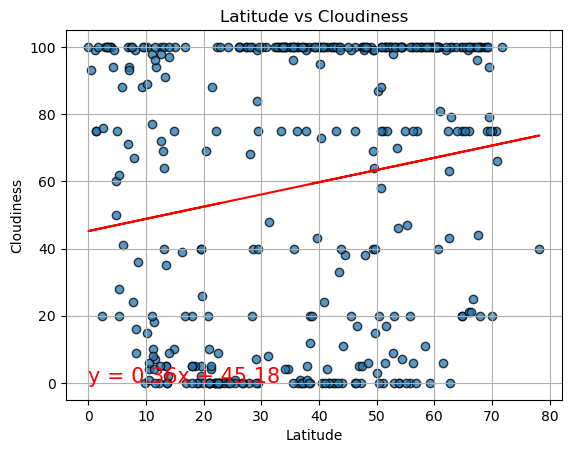

The R^2 value for Northern Hemisphere is: 0.02975512720729615


In [20]:
# Northern Hemisphere
slope, intercept, r_value, p_value, std_err = linregress(northern_hemi_df["Lat"], northern_hemi_df["Cloudiness"])
lat = ["northern_hemi_df"]
regress_values = slope * northern_hemi_df["Lat"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
plt.scatter(northern_hemi_df["Lat"], northern_hemi_df["Cloudiness"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)
plt.plot(northern_hemi_df["Lat"], regress_values, "r-", label="Regression Line")
plt.annotate(line_eq, (min(northern_hemi_df["Lat"]), min(northern_hemi_df["Cloudiness"])), fontsize=15, color="red")
plt.title("Latitude vs Cloudiness")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness")
plt.grid(True)
plt.show()
r_squared = r_value ** 2
print(f"The R^2 value for Northern Hemisphere is: {r_squared}")

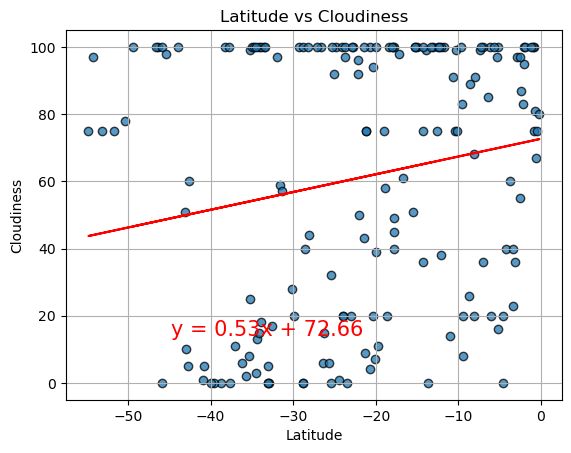

The R^2 value for Southern Hemisphere is: 0.03501113006784096


In [21]:
# Southern Hemisphere
slope, intercept, r_value, p_value, std_err = linregress(southern_hemi_df["Lat"], southern_hemi_df["Cloudiness"])
lat = ["southern_hemi_df"]
regress_values = slope * southern_hemi_df["Lat"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
plt.scatter(southern_hemi_df["Lat"], southern_hemi_df["Cloudiness"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)
plt.plot(southern_hemi_df["Lat"], regress_values, "r-", label="Regression Line")
plt.annotate(line_eq, (min(southern_hemi_df["Lat"])+10, min(southern_hemi_df["Cloudiness"])+14), fontsize=15, color="red")
plt.title("Latitude vs Cloudiness")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness")
plt.grid(True)
plt.show()
r_squared = r_value ** 2
print(f"The R^2 value for Southern Hemisphere is: {r_squared}")

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Wind Speed vs. Latitude Linear Regression Plot

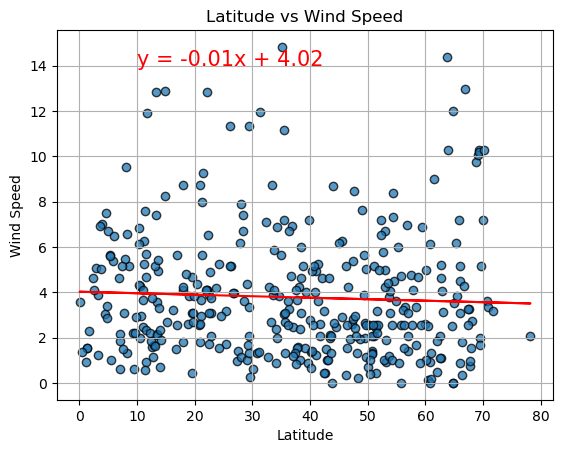

The R^2 value for Northern Hemisphere is: 0.0023036222113049206


In [22]:
# Northern Hemisphere
slope, intercept, r_value, p_value, std_err = linregress(northern_hemi_df["Lat"], northern_hemi_df["Wind Speed"])
lat = ["northern_hemi_df"]
regress_values = slope * northern_hemi_df["Lat"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
plt.scatter(northern_hemi_df["Lat"], northern_hemi_df["Wind Speed"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)
plt.plot(northern_hemi_df["Lat"], regress_values, "r-", label="Regression Line")
plt.annotate(line_eq, (min(northern_hemi_df["Lat"])+10, min(northern_hemi_df["Wind Speed"])+14), fontsize=15, color="red")
plt.title("Latitude vs Wind Speed")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed")
plt.grid(True)
plt.show()
r_squared = r_value ** 2
print(f"The R^2 value for Northern Hemisphere is: {r_squared}")

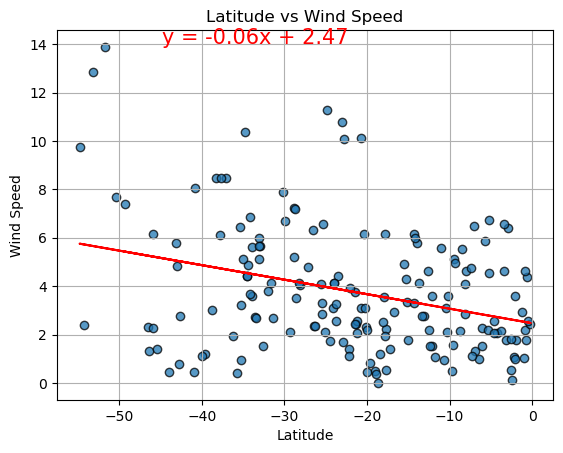

The R^2 value for Southern Hemisphere is: 0.10154556609851934


In [23]:
# Southern Hemisphere
slope, intercept, r_value, p_value, std_err = linregress(southern_hemi_df["Lat"], southern_hemi_df["Wind Speed"])
lat = ["southern_hemi_df"]
regress_values = slope * southern_hemi_df["Lat"] + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"
plt.scatter(southern_hemi_df["Lat"], southern_hemi_df["Wind Speed"], edgecolors="black", linewidths=1, marker="o", alpha=0.75)
plt.plot(southern_hemi_df["Lat"], regress_values, "r-", label="Regression Line")
plt.annotate(line_eq, (min(southern_hemi_df["Lat"])+10, min(southern_hemi_df["Wind Speed"])+14), fontsize=15, color="red")
plt.title("Latitude vs Wind Speed")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed")
plt.grid(True)
plt.show()
r_squared = r_value ** 2
print(f"The R^2 value for Southern Hemisphere is: {r_squared}")

**Discussion about the linear relationship: The latitude of a location provides almost no insight into the wind speed.